# LSTM Fake News Detection Experiment

This notebook demonstrates an LSTM-based approach for fake news detection:

1. **Data Processing**: Load raw data, clean source attribution, remove duplicates
2. **Train/Test Split**: Stratified split with configurable columns
3. **Text Tokenization**: Build vocabulary and convert text to padded sequences
4. **LSTM Model**: PyTorch LSTM classifier with embedding layer
5. **Evaluation**: Accuracy, precision, recall, F1-score

**Based on**: pipeline_v3.ipynb with traditional ML replaced by deep learning.


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from collections import Counter
import re

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Sklearn for metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules
from src.data import process_dataset, make_split
from src.models import train_model as train_model_module

load_config = train_model_module.load_config

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print("✓ Imports successful")


Using device: mps
✓ Imports successful


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution (e.g., "(Reuters) -"), and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...


   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 27,695 duplicates
   Remaining: 44,439 unique articles

4. Label distribution ('label' column):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

5. Saving cleaned data...
✓ Saved 44439 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     44,439
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)

print(f"\nTrain set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 44,439 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (35,551 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (8,888 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  35,551
  Test samples:   8,888

Train set: 35551 samples
Test set: 8888 samples


## 3. Text Tokenization for LSTM

Build vocabulary from training data and convert text to padded integer sequences.


In [5]:
# LSTM Hyperparameters
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 256
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
DROPOUT = 0.3
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001

print("LSTM Hyperparameters:")
print(f"  Vocab size: {VOCAB_SIZE}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Hidden dimension: {HIDDEN_DIM}")
print(f"  Dropout: {DROPOUT}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")


LSTM Hyperparameters:
  Vocab size: 10000
  Max sequence length: 256
  Embedding dimension: 128
  Hidden dimension: 64
  Dropout: 0.3
  Batch size: 64
  Epochs: 100
  Learning rate: 0.001


In [6]:
def simple_tokenize(text):
    """Simple tokenizer: lowercase, keep alphanumeric, split on whitespace."""
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()


class Vocabulary:
    """Build vocabulary from text data."""
    
    def __init__(self, max_size=10000):
        self.max_size = max_size
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        
    def build(self, texts):
        """Build vocabulary from list of texts."""
        word_counts = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = simple_tokenize(text)
            word_counts.update(tokens)
        
        # Keep top max_size - 2 words (accounting for PAD and UNK)
        most_common = word_counts.most_common(self.max_size - 2)
        
        for word, _ in most_common:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            
        print(f"  Vocabulary built: {len(self.word2idx)} unique tokens")
        return self
    
    def encode(self, text, max_len=256):
        """Convert text to padded sequence of indices."""
        tokens = simple_tokenize(text)
        indices = [self.word2idx.get(t, 1) for t in tokens]  # 1 = UNK
        
        # Truncate or pad
        if len(indices) > max_len:
            indices = indices[:max_len]
        else:
            indices = indices + [0] * (max_len - len(indices))  # 0 = PAD
            
        return indices
    
    def __len__(self):
        return len(self.word2idx)


# Build vocabulary from training data
print("Building vocabulary from training data...")
vocab = Vocabulary(max_size=VOCAB_SIZE)
vocab.build(train_df[FEATURE_COLUMN].tolist())


Building vocabulary from training data...


Building vocabulary: 100%|██████████| 35551/35551 [00:13<00:00, 2574.17it/s]


  Vocabulary built: 10000 unique tokens


In [7]:
class TextDataset(Dataset):
    """PyTorch Dataset for text classification."""
    
    def __init__(self, texts, labels, vocab, max_len=256):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoded = self.vocab.encode(text, self.max_len)
        
        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.float)
        }


# Create datasets
print("Creating datasets...")
train_dataset = TextDataset(
    train_df[FEATURE_COLUMN].tolist(),
    train_df[LABEL_COLUMN].tolist(),
    vocab,
    max_len=MAX_SEQ_LEN
)

test_dataset = TextDataset(
    test_df[FEATURE_COLUMN].tolist(),
    test_df[LABEL_COLUMN].tolist(),
    vocab,
    max_len=MAX_SEQ_LEN
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")


Creating datasets...
  Train batches: 556
  Test batches: 139


## 4. LSTM Model

Define the LSTM classifier with embedding layer.


In [8]:
class LSTMClassifier(nn.Module):
    """LSTM-based text classifier for fake news detection."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        # LSTM output - use the last output from the sequence
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use the last time step output instead of hidden state
        # lstm_out: (batch, seq_len, hidden_dim)
        last_output = lstm_out[:, -1, :]  # (batch, hidden_dim)
        
        # Apply dropout and FC layer
        dropped = self.dropout(last_output)
        output = self.fc(dropped)  # (batch, 1)
        
        return output.view(-1)  # Flatten to (batch,)


# Initialize model
model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(device)

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model architecture:
LSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 1,329,729
Trainable parameters: 1,329,729


## 5. Training

Train the LSTM model with binary cross-entropy loss.


In [9]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), accuracy, all_preds, all_labels


In [ ]:
# Training loop with early stopping
print("="*60)
print("LSTM MODEL TRAINING")
print("="*60)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Early stopping setup
patience = 20
best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate
    val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        # Save best model state
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best model saved (val_loss: {best_val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement}/{patience} epochs")
        
        if epochs_without_improvement >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch + 1}")
            break

# Restore best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Restored best model weights (val_loss: {best_val_loss:.4f})")

print("\n" + "="*60)
print("✓ TRAINING COMPLETE")
print("="*60)
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"  Total epochs trained: {len(history['train_loss'])}")

LSTM MODEL TRAINING

Epoch 1/100
----------------------------------------


  Train Loss: 0.6171 | Train Acc: 0.6633
  Val Loss:   0.5520 | Val Acc:   0.7366
  ✓ New best model saved (val_loss: 0.5520)

Epoch 2/100
----------------------------------------


  Train Loss: 0.5251 | Train Acc: 0.7503
  Val Loss:   0.5090 | Val Acc:   0.7059
  ✓ New best model saved (val_loss: 0.5090)

Epoch 3/100
----------------------------------------


  Train Loss: 0.4250 | Train Acc: 0.8226
  Val Loss:   0.3904 | Val Acc:   0.8417
  ✓ New best model saved (val_loss: 0.3904)

Epoch 4/100
----------------------------------------


  Train Loss: 0.5423 | Train Acc: 0.7281
  Val Loss:   0.4740 | Val Acc:   0.8351
  No improvement for 1/20 epochs

Epoch 5/100
----------------------------------------


...

  Train Loss: 0.1237 | Train Acc: 0.9624
  Val Loss:   0.2306 | Val Acc:   0.9275
  No improvement for 2/20 epochs

Epoch 13/100
----------------------------------------


  Train Loss: 0.0938 | Train Acc: 0.9746
  Val Loss:   0.2555 | Val Acc:   0.9288
  No improvement for 3/20 epochs

Epoch 14/100
----------------------------------------


  Train Loss: 0.0769 | Train Acc: 0.9796
  Val Loss:   0.2496 | Val Acc:   0.9226
  No improvement for 4/20 epochs

Epoch 15/100
----------------------------------------


  Train Loss: 0.0654 | Train Acc: 0.9832
  Val Loss:   0.2709 | Val Acc:   0.9269
  No improvement for 5/20 epochs

Epoch 16/100
----------------------------------------


Training:  14%|█▍        | 80/556 [00:14<01:10,  6.73it/s]

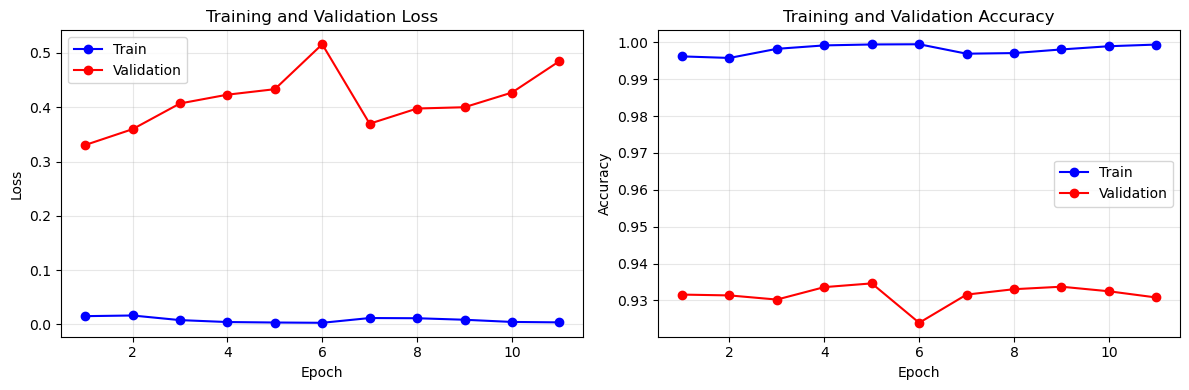

In [ ]:
# Plot training history
num_epochs_trained = len(history['train_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(range(1, num_epochs_trained + 1), history['train_loss'], 'b-o', label='Train')
ax1.plot(range(1, num_epochs_trained + 1), history['val_loss'], 'r-o', label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(range(1, num_epochs_trained + 1), history['train_acc'], 'b-o', label='Train')
ax2.plot(range(1, num_epochs_trained + 1), history['val_acc'], 'r-o', label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

Final evaluation on test set with detailed metrics.


In [ ]:
# Final evaluation
print("="*60)
print("MODEL EVALUATION: LSTM Classifier")
print("="*60)

test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)

print(f"\n1. Data summary:")
print(f"   Feature source: '{FEATURE_COLUMN}' column → LSTM sequences")
print(f"   Label source:   '{LABEL_COLUMN}' column (0=Real, 1=Fake)")
print(f"\n   Test samples: {len(y_true)}")

print(f"\n2. Test Results:")
print(f"   Accuracy: {test_acc:.4f}")

print(f"\n3. Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=['Real (0)', 'Fake (1)'],
    digits=2
))

print("="*60)
print("✓ EVALUATION COMPLETE: LSTM Classifier")
print("="*60)
print(f"  Features: '{FEATURE_COLUMN}' → LSTM (vocab={len(vocab)}, seq_len={MAX_SEQ_LEN})")
print(f"  Labels:   '{LABEL_COLUMN}' (0=Real, 1=Fake)")
print(f"  Accuracy: {test_acc:.4f}")


MODEL EVALUATION: LSTM Classifier


Evaluating:   0%|          | 0/139 [00:00<?, ?it/s]


1. Data summary:
   Feature source: 'text' column → LSTM sequences
   Label source:   'label' column (0=Real, 1=Fake)

   Test samples: 8888

2. Test Results:
   Accuracy: 0.9316

3. Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.94      0.96      0.95      5912
    Fake (1)       0.92      0.87      0.90      2976

    accuracy                           0.93      8888
   macro avg       0.93      0.92      0.92      8888
weighted avg       0.93      0.93      0.93      8888

✓ EVALUATION COMPLETE: LSTM Classifier
  Features: 'text' → LSTM (vocab=10000, seq_len=256)
  Labels:   'label' (0=Real, 1=Fake)
  Accuracy: 0.9316


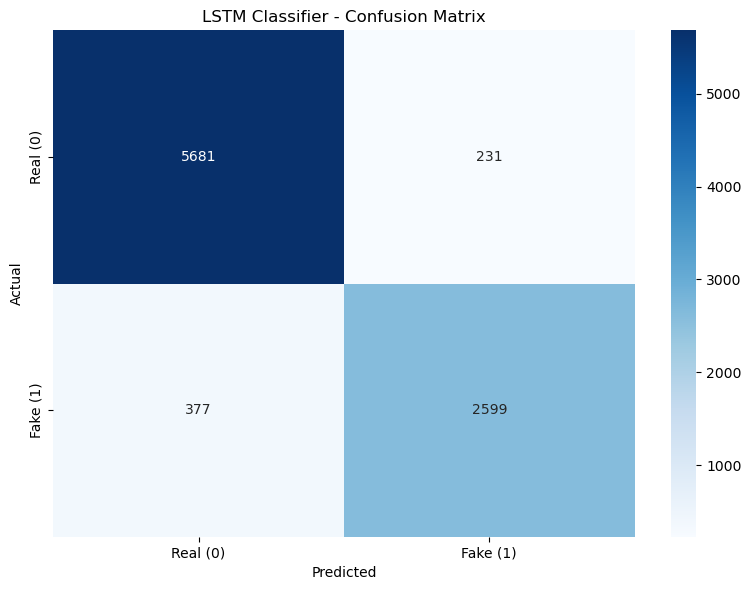


Confusion Matrix Breakdown:
  True Negatives (Real correctly classified):  5681
  False Positives (Real misclassified as Fake): 231
  False Negatives (Fake misclassified as Real): 377
  True Positives (Fake correctly classified):  2599


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Real correctly classified):  {cm[0][0]}")
print(f"  False Positives (Real misclassified as Fake): {cm[0][1]}")
print(f"  False Negatives (Fake misclassified as Real): {cm[1][0]}")
print(f"  True Positives (Fake correctly classified):  {cm[1][1]}")


In [ ]:
# Save model (optional)
model_save_path = project_root / "results" / "models" / "lstm_classifier.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_word2idx': vocab.word2idx,
    'hyperparameters': {
        'vocab_size': len(vocab),
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'max_seq_len': MAX_SEQ_LEN
    },
    'test_accuracy': test_acc
}, model_save_path)

print(f"✓ Model saved to: {model_save_path}")


✓ Model saved to: /Users/alanye/Fake-News-Group-3/results/models/lstm_classifier.pt


## Summary

This LSTM experiment provides a baseline deep learning approach for fake news detection.

**Key findings:**
- LSTM captures sequential patterns in text
- Simple architecture with embedding + LSTM + FC layers
- Comparable to traditional ML baselines (Ridge, Logistic Regression)

**Potential improvements:**
- Use pre-trained embeddings (GloVe, Word2Vec)
- Try bidirectional LSTM
- Add attention mechanism
- Experiment with transformer models (BERT, RoBERTa)
